# Clean LLM Delta Heatmap

Regenerate `llm_delta_heatmap.png` from `llm_scheduler.jsonl` while removing cluttered/repeated x-axis steps.

Default cleanup:
- Drop step `402`, because it is too close to `401`.
- Keep only the first occurrence of duplicate steps, so the second `502` is removed.

In [1]:
from pathlib import Path
import json
import shutil

import matplotlib.pyplot as plt
import numpy as np

## Config

In [2]:
run_dir = Path("outputs/nvidia_meta_20260601_152616")
jsonl_path = run_dir / "llm_scheduler.jsonl"
figure_path = run_dir / "figures" / "llm_delta_heatmap.png"
backup_path = run_dir / "figures" / "llm_delta_heatmap_original_with_duplicate_ticks.png"

# Steps to remove even if they are unique.
drop_steps = {402}

# If True, keep the first occurrence of a duplicate global_step and drop later ones.
drop_duplicate_steps = True

print("JSONL:", jsonl_path)
print("Output:", figure_path)

JSONL: outputs\nvidia_meta_20260601_152616\llm_scheduler.jsonl
Output: outputs\nvidia_meta_20260601_152616\figures\llm_delta_heatmap.png


## Load And Filter Records

In [3]:
records = []
with jsonl_path.open("r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

seen_steps = set()
clean_records = []
removed = []

for record in records:
    step = int(record["global_step"])
    reason = None
    if step in drop_steps:
        reason = "configured_drop"
    elif drop_duplicate_steps and step in seen_steps:
        reason = "duplicate"

    if reason:
        removed.append({"global_step": step, "reason": reason, "llm_calls": record.get("llm_calls")})
        continue

    clean_records.append(record)
    seen_steps.add(step)

steps = [int(r["global_step"]) for r in clean_records]
task_names = list(clean_records[0]["candidate_task_names"])
delta_arr = np.asarray([r["cached_llm_delta"] for r in clean_records], dtype=float).T

print("Original records:", len(records))
print("Clean records:", len(clean_records))
print("Removed:", removed)
print("Steps:", steps)
print("Delta shape:", delta_arr.shape)

Original records: 31
Clean records: 31
Removed: []
Steps: [1, 34, 67, 101, 134, 167, 201, 234, 267, 301, 334, 367, 401, 435, 468, 502, 535, 602, 702, 802, 902, 1002, 1102, 1202, 1302, 1402, 1502, 1602, 1702, 1802, 1902]
Delta shape: (7, 31)


## Plot And Save

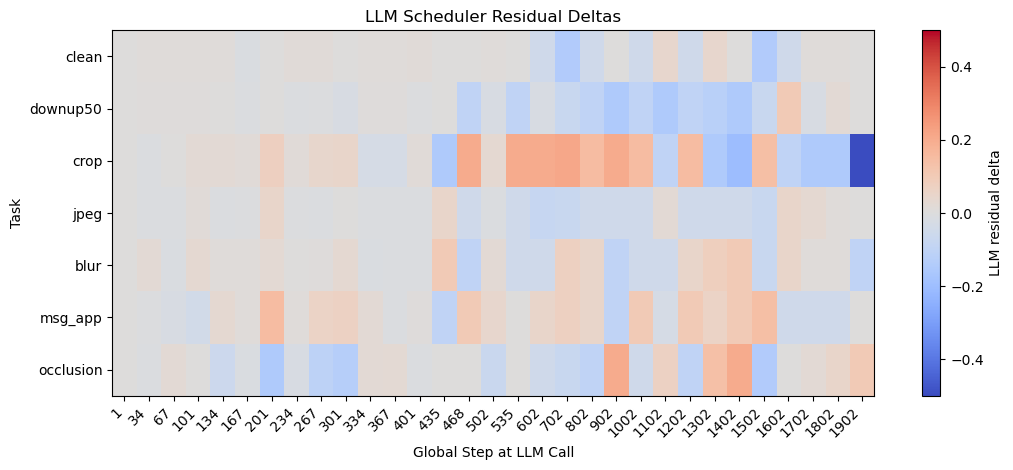

Saved cleaned heatmap: outputs\nvidia_meta_20260601_152616\figures\llm_delta_heatmap.png


In [4]:
if figure_path.exists() and not backup_path.exists():
    shutil.copy2(figure_path, backup_path)
    print("Backup saved:", backup_path)

fig_w = max(10, 0.35 * len(steps))
fig, ax = plt.subplots(figsize=(fig_w, 4.8))

vmax = max(1e-6, float(np.max(np.abs(delta_arr))))
im = ax.imshow(delta_arr, aspect="auto", cmap="coolwarm", vmin=-vmax, vmax=vmax)

ax.set_title("LLM Scheduler Residual Deltas")
ax.set_xlabel("Global Step at LLM Call")
ax.set_ylabel("Task")
ax.set_yticks(np.arange(len(task_names)))
ax.set_yticklabels(task_names)
ax.set_xticks(np.arange(len(steps)))
ax.set_xticklabels(steps, rotation=45, ha="right")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("LLM residual delta")

fig.tight_layout()
fig.savefig(figure_path, dpi=160)
plt.show()

print("Saved cleaned heatmap:", figure_path)